# **REDUCCIÓN DE DIMENSIONALIDAD**

Cuantas más dimensiones tengamos más registros necesitaremos para poder representar todas las combinaciones posibles y nuestro modelo se hace más complejo aumentando las posibilidades de overfitting ya que se hace más dependiente de los datos con los que se ha entrenado.

El overfitting o sobreajuste ocurre cuando el modelo depende demasiado de un conjunto de datos, funcionando muy bien para estos pero haciendo predicciones poco fiables para el resto.


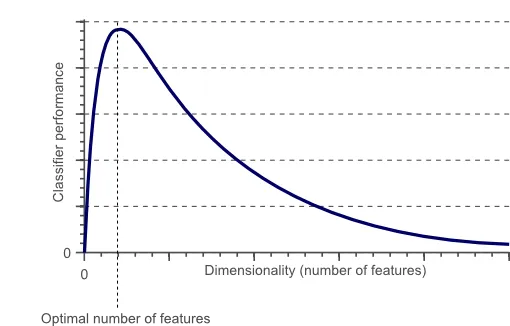


Los métodos de filtro realizan una selección de características independientemente del algoritomo de aprendizaje.

Las características se clasifican según una puntación que determina la correlación de las mismas con la variable de resultado.

## **Varianza**

Se pueden eliminar variables irrelevantes analizando su variabilidad. Las variables cuya desviación estándar es cero son constantes y, por lo tanto, podemos eliminarlas.

In [2]:
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.feature_selection import VarianceThreshold

# make_classification crea un conjunto de datos multiclase asignando a cada clase uno o más
# conglomerados de puntos distribuidos normalmente
# https://qu4nt.github.io/sklearn-doc-es/datasets/sample_generators.html#sample-generators

# Set de datos con 10 variables, 3 de las cuales son constantes.
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    random_state=10,
)
X = pd.DataFrame(X)
X[[0, 5, 9]] = 1

X

,0,1,2,3,4,5,6,7,8,9
0,1,-0.376539,-0.620180,-0.157567,-1.120805,1,-1.574578,1.678046,1.080180,1
1,1,0.762409,-0.784210,-0.096479,-0.408758,1,0.210942,-0.850449,-0.461301,1
2,1,2.227934,0.547727,-0.341481,-0.817577,1,-2.663678,2.440042,1.698919,1
3,1,0.061129,-0.995868,-0.214351,-0.558957,1,-2.149167,2.294192,-1.383965,1
4,1,0.046349,0.834756,-0.104845,-0.455528,1,-0.911018,0.898098,1.068259,1
...,...,...,...,...,...,...,...,...,...,...
995,1,-0.056868,-0.336122,-0.700527,0.129147,1,-1.850227,-0.770335,-0.888264,1
996,1,0.566137,0.627820,-0.049620,1.765735,1,0.046187,-0.337826,-0.161875,1
997,1,0.743103,1.136757,-0.103349,-0.769979,1,-2.125616,2.847156,-0.911452,1
998,1,-1.433237,-2.549200,0.134018,1.092140,1,0.197284,0.397779,-0.716400,1


In [3]:
# Las características con una varianza del conjunto de entrenamiento inferior al
# umbral establecido mediante el parámetro threshold se eliminan

# Eliminar variables constantes (threshold=0)
sel = VarianceThreshold (threshold=0)
X_t = sel.fit_transform(X)

X_t.shape

(1000, 7)

Se eliminan todas las características con una varianza del conjunto de entrenamiento inferior al umbral establecido mediante el parámetro threshold.

## **Correlación de Pearson (1)**

El coeficiente de correlación de Pearson se calcula mediante la siguiente ecuación:



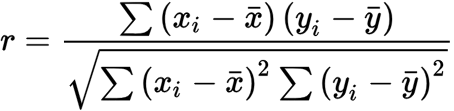


La expresión en el denominador garantiza que el coeficiente de correlación se escala entre -1 y 1.

In [4]:
# Analyse the relationship between 'TV advertising' and 'sales'
#
# https://www.kaggle.com/datasets/ashydv/advertising-dataset/

import pandas as pd
import matplotlib.pyplot as plt

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_csv('/content/drive/MyDrive/SAA/data_folder/advertising.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SAA/data_folder/advertising.csv'

In [ ]:
df.info()

In [ ]:
df.corr(method="pearson")

Lo que se busca es un modelo que prediga las ventas en función de lo que se gasta en publicidad. En este sentido, la variable TV es la que tiene más correlación con las ventas, esto es, la que más influye.

In [ ]:
plt.plot(df['TV'], df['Sales'], 'ro')
plt.ylabel("Sales")
plt.xlabel("TV")

In [ ]:
plt.plot(df['Newspaper'], df['Sales'], 'ro')
plt.ylabel("Sales")
plt.xlabel("Newspaper")

## **LDA (Linear Discriminant Analysis)**

LDA es un algoritmo de aprendizaje supervisado que se usa para tareas de clasificación. Como busca la combinación de características que mejor separan las clases en un dataset también se usa en reducción de dimensionalidad.

LDA tiene algunas limitaciones, ya que los datos deben de tener una distribución gausiana y que las matrices de covarianza de las diferentes clases sean parecidas. La covarianza es un valor que indica el grado de variación conjunta de dos variables respecto a sus medias.

El dataset iris contiene datos de 150 flores de 3 especies diferentes de la misma planta. Para cada flor tenemos 4 variables: sepal length, sepal width, petal length y petal width.

In [ ]:
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# load the iris dataset
iris = load_iris()

In [ ]:
iris.data[50:100,0]

In [ ]:
iris.target[50:100]

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3)
fig.suptitle('Longitud del sépalo en cm')
# Los primeros 50 pertenecen a Iris setosa
sb.histplot(iris.data[:50, 0], ax=ax1, kde=True).set_title('Setosa')
# Los siguientes 50 pertenecen a Iris versicolor
sb.histplot(iris.data[50:100, 0], ax=ax2, kde=True).set_title('Versicolor')
# Los 50 últimos son de la clase Iris virginica
sb.histplot(iris.data[100:150, 0], kde=True, ax=ax3).set_title('Virginica')


In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3)
fig.suptitle('Anchura del sépalo en cm')
# Los primeros 50 pertenecen a Iris setosa
sb.histplot(iris.data[:50, 1], ax=ax1, kde=True).set_title('Setosa')
# Los siguientes 50 pertenecen a Iris versicolor
sb.histplot(iris.data[50:100, 1], ax=ax2, kde=True).set_title('Versicolor')
# Los 50 últimos son de la clase Iris virginica
sb.histplot(iris.data[100:150, 1], kde=True, ax=ax3).set_title('Virginica')

Lo mismo pasaría para el resto de atributos, con lo que podemos concluir que las variables tienen una distribución gausiana, esto es, los valores se agrupan en torno a punto central.

La covarianza es una medida estadística que describe cómo se mueven dos variables cuantitativas conjuntamente. Si es positiva, las variables tienden a aumentar y disminuir juntas; si es negativa, una aumenta mientras la otra disminuye. Una covarianza de cero o cercana a cero sugiere que no hay una relación lineal entre ellas.



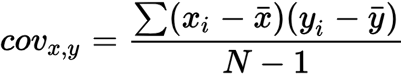

En estadística, la covarianza se utiliza para medir la relación lineal entre dos variables aleatorias. La covarianza indica si dos variables aumentan o disminuyen juntas en tándem. Sin embargo, la covarianza no es una medida estandarizada y su magnitud depende de la escala de las variables, lo que dificulta su interpretación.

Por lo tanto, se utiliza la correlación como medida complementaria para evaluar la fuerza y dirección de la relación entre las variables. La correlación indica tanto la fuerza como la dirección de la relación lineal entre dos variables aleatorias.

En particular, la correlación es útil para analizar múltiples variables que expresan una relación lineal entre sí.

In [ ]:
# Vamos a calcular la matriz de varianzas y covarianzas
df = pd.DataFrame(iris.data[:50], columns=["sepal_length", "sepal_width", "petal_length", "petal_width"])
df.cov()


In [ ]:
df = pd.DataFrame(iris.data[50:100], columns=["sepal_length", "sepal_width", "petal_length", "petal_width"])
df.cov()

In [ ]:
# divide the dataset into class and target variable
X = iris.data
y = iris.target

# Preprocess the dataset and divide into train and test
sc = StandardScaler()
X = sc.fit_transform(X)
# LabelEncoder() tranforma etiquetas no numéricas en etiquetas numéricas
# En este ejemplo no haría falta ya que el atributo objetivo ya está codificado: 0 para setosa, 1 versicolor y 2 virginica
# Se mantiene como ejemplo
le = LabelEncoder()
y = le.fit_transform(y)

Normalizar es escalar los datos para que el rango de valores resultante esté entre 0 y 1, por lo general, y requiere conocer cual es el valor mínimo y máximo del universo para realizar la operación.

Estandarizar se refiere a escalar la distribución de los datos de forma tal que la media de los valores observados sea igual a 0 y su desviación estándar igual a 1.

En general, los algoritmos de machine learning que se basen sobre la hipótesis que los datos poseen una distribución gaussiana requieren que los mismos sean estandarizados. Sin embargo, la selección de la manera de escalar la data no es una tarea de una sola vía, depende mucho de las circunstancias y de los resultados del análisis descriptivo inicial del problema.

In [ ]:
# apply Linear Discriminant Analysis
lda = LinearDiscriminantAnalysis(n_components=2)
# Devuelve una versión transformada de X
X_lda = lda.fit_transform(X, y)

# plot the scatterplot
plt.scatter (X_lda[:,0], X_lda[:,1], c=y, cmap='rainbow', alpha=0.7, edgecolors='b')

In [ ]:
lda.get_feature_names_out()

## **ANOVA (Analysis of variance)**

El análisis de la varianza (ANOVA) comprueba si existen diferencias estadísticamente significativas entre más de dos muestras. Para ello, se comparan entre sí las medias y las varianzas de los respectivos grupos.

Determina si las medias de dos o más conjuntos de datos provienen de la misma distribución.

El resultado de este test se puede usar para selección de atributos ya que si son independientes del atributo objetivo se pueden eliminar del dataset.

### **Ejemplo 1 (2)**

Una empresa de materiales de construcción quiere estudiar la influencia que tienen el grosor y el tipo de templado sobre la resistencia máxima de unas láminas de acero. Para ello miden el estrés hasta la rotura (variable cuantitativa dependiente) para dos tipos de templado (lento y rápido) y tres grosores de lámina (8mm, 16mm y 24 mm).

In [ ]:
!pip install pingouin

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from statsmodels.graphics.factorplots import interaction_plot

Pingouin es un paquete open-source de estadísticas

In [ ]:
resistencia = [15.29, 15.89, 16.02, 16.56, 15.46, 16.91, 16.99, 17.27, 16.85,
               16.35, 17.23, 17.81, 17.74, 18.02, 18.37, 12.07, 12.42, 12.73,
               13.02, 12.05, 12.92, 13.01, 12.21, 13.49, 14.01, 13.30, 12.82,
               12.49, 13.55, 14.53]

templado = ["rapido"] * 15 + ["lento"] * 15

grosor = ([8] * 5 + [16] * 5 + [24] * 5) * 2

datos = pd.DataFrame({
    'templado': templado,
    'grosor': grosor,
    'resistencia': resistencia
})

datos.head(30)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].set_title('Resistencia vs templado')
sns.boxplot(x="templado", y="resistencia", data=datos, ax=axs[0])
sns.swarmplot(x="templado", y="resistencia", data=datos, color='black',
              alpha = 0.5, ax=axs[0])

axs[1].set_title('Resistencia vs grosor')
sns.boxplot(x="grosor", y="resistencia", data=datos, ax=axs[1])
sns.swarmplot(x="grosor", y="resistencia", data=datos, color='black',
              alpha = 0.5, ax=axs[1]);

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.set_title('Resistencia vs templado y grosor')
sns.boxplot(x="templado", y="resistencia", hue='grosor', data=datos, ax=ax);

In [ ]:
print('Resistencia media y desviación típica por templado')
datos.groupby('templado')['resistencia'].agg(['mean', 'std'])


In [ ]:
print('Resistencia media y desviación típica por grosor')
datos.groupby('grosor')['resistencia'].agg(['mean', 'std'])

In [ ]:
print('Resistencia media y desviación típica por templado y grosor')
datos.groupby(['templado', 'grosor'])['resistencia'].agg(['mean', 'std'])

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x        = datos.templado,
    trace    = datos.grosor,
    response = datos.resistencia,
    ax       = ax,
)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x        = datos.grosor,
    trace    = datos.templado,
    response = datos.resistencia,
    ax       = ax,
)

In [ ]:
# Test ANOVA de dos vías (Two-way ANOVA)
# El análisis de varianza de dos factores comprueba si existe una diferencia entre más de dos muestras independientes divididas entre dos variables o factores.
# ==============================================================================

pg.anova(
    data     = datos,
    dv       = 'resistencia',
    between  = ['templado', 'grosor'],
    detailed = True
).round(4)

SS (Sum of Squares) es la suma de los cuadrados de cada valor individual menos la media.

DF son los grados de libertad: número de grupos menos 1.

MS (Mean Squares) es el cociente entre SS y DF.

Se usa la prueba F para determinar si las medias de los grupos son iguales. En un ANOVA de un solo factor, la estadística F es una proporción:

F = variación entre las medias de las muestras / variación dentro de las muestras

En general, una estadística F es un cociente de dos cantidades que se espera que sean aproximadamente iguales bajo la hipótesis nula, lo que produce una estadística F de aproximadamente 1.

El valor p se utiliza para tomar una decisión. Si el valor p es menor que el nivel de significancia (normalmente 0,05), se rechaza la hipótesis nula.

La hipótesis nula es la suposición inicial de un estudio que establece que no hay efecto, diferencia o relación entre las variables que se están investigando.

**INTERPRETACIÓN**

La primera fila comprueba si el templado influye en la resistencia, la segunda comprueba si el grosor influye en la resistencia y la tercera comprueba si templado y grosor tienen efectos el uso sobre el otro.

Cómo p es inferior a 0.05 tanto el templado como el grosor influyen en la resistencia.

El análisis de varianza confirma que existe una influencia significativa sobre la resistencia de las láminas por parte de ambos factores (templado y grosor) con tamaños de efecto  η2 grande y mediano respectivamente. Sin embargo, no se detecta una interacción significativa entre ellos.

### **Ejemplo 2**

In [ ]:

import pandas as pd
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from matplotlib import pyplot


In [ ]:
names=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('/content/drive/MyDrive/SAA/data_folder/pima-indians-diabetes.csv', names = names)
df.info()

In [ ]:
X=df.drop('Outcome', axis = 1)
y=df['Outcome']

SelectKBest es uno de los algoritmos de selección de características de filtro más usados. Usa test estadísticos del tipo chi-squared, ANOVA F, ... para establecer un rango para las diferentes variables en función de su relación con la variable objetivo.

Tiene dos parámetros, uno de los cuales es score function, que, en nuestro caso, es f_classif, que se usa en problemas de clasificación y se basa en valores ANOVA F.



In [ ]:
bestfeatures = SelectKBest (score_func=f_classif)
X_new = bestfeatures.fit(X,y)
print(X_new.scores_)
print(X_new.pvalues_)

In [ ]:
# what are scores for the features
for i in range(len(X_new.scores_)):
 print('Feature %d: %f' % (i, X_new.scores_[i]))
# plot the scores
pyplot.bar([i for i in range(len(X_new.scores_))], X_new.scores_)
pyplot.show()

## **chi-square**

En 1900, Karl Pearson publicó un artículo sobre la prueba χ2, que se considera uno de los fundamentos de la estadística moderna.


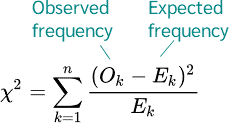

La prueba Chi-cuadrado es una prueba de hipótesis utilizada para determinar si existe una relación entre dos variables categóricas.

Por ejemplo: influye el sexo en que una persona esté o no suscrita a Netflix? Para las dos variables, sexo (hombre, mujer) y tiene suscripción a Netflix (sí, no), se comprueba si son independientes. Si no es así, existe una relación entre las características. (3)


La pregunta de investigación que puede responderse con la prueba Chi-cuadrado es: ¿Son independientes entre sí las características de sexo y posesión de una suscripción a Netflix?

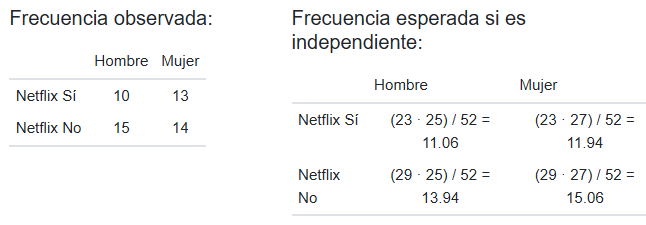

El valor Chi-cuadrado se calcula entonces como:

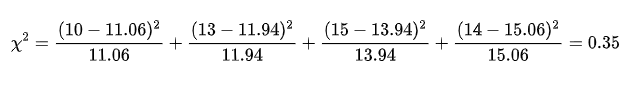

La interpretación del chi-cuadrado depende de si el valor calculado es mayor o menor que el valor crítico (o si el valor p es menor que el nivel de significancia, como 0.05). Un valor de chi-cuadrado mayor indica una diferencia significativa entre las frecuencias observadas y las esperadas, lo que sugiere que existe una asociación o relación entre las variables. Un valor menor sugiere que la diferencia es pequeña y puede deberse al azar, por lo que se no se rechaza la hipótesis nula.


### **Ejemplo 1**

In [7]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import chi2

# load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# use SelectPercentile to select top 30 percentile of features
selector = SelectPercentile(chi2, percentile=30)
X_selected = selector.fit_transform(X, y)

# get the selected features
selected_features = selector.get_support(indices=True)

# print the selected feature indices
print(selected_features)

[2]


### **Ejemplo 2**

In [ ]:
import pandas as pd
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import f_classif,chi2
from sklearn.preprocessing import Binarizer, scale
from matplotlib import pyplot

names=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('/content/drive/MyDrive/SAA/data_folder/pima-indians-diabetes.csv', names = names)

X=df.drop('Outcome', axis = 1)
y=df['Outcome']

# Binarizer establece los valores de las características en 0 o 1, según el umbral
X_bin = Binarizer().fit_transform(scale(X))
selectChi2 = SelectPercentile(chi2, percentile=30).fit(X_bin, y)
chi2_selected = selectChi2.get_support()
chi2_selected_features = [ f for i,f in enumerate(X.columns) if chi2_selected[i]]
print('Chi2 selected {} features {}.'.format(chi2_selected.sum(), chi2_selected_features))
print (bestfeatures)


# **Column Transformer with Mixed Types (4)**

This example illustrates how to apply different preprocessing and feature extraction pipelines to different subsets of features, using ColumnTransformer. This is particularly handy for the case of datasets that contain heterogeneous data types, since we may want to scale the numeric features and one-hot encode the categorical ones.

In this example, the numeric data is standard-scaled after mean-imputation. The categorical data is one-hot encoded via OneHotEncoder, which creates a new category for missing values. We further reduce the dimensionality by selecting categories using a chi-squared test.

In addition, we show two different ways to dispatch the columns to the particular pre-processor: by column names and by column data types.

Finally, the preprocessing pipeline is integrated in a full prediction pipeline using Pipeline, together with a simple classification model.

In [9]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.feature_selection import SelectPercentile, chi2
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(0)

In [11]:
# Load data from https://www.openml.org/d/40945

X, y = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True, parser="pandas")

# Alternatively X and y can be obtained directly from the frame attribute:
# X = titanic.frame.drop('survived', axis=1)
# y = titanic.frame['survived']

In [12]:
X.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [13]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   name       1309 non-null   object  
 2   sex        1309 non-null   category
 3   age        1046 non-null   float64 
 4   sibsp      1309 non-null   int64   
 5   parch      1309 non-null   int64   
 6   ticket     1309 non-null   object  
 7   fare       1308 non-null   float64 
 8   cabin      295 non-null    object  
 9   embarked   1307 non-null   category
 10  boat       486 non-null    object  
 11  body       121 non-null    float64 
 12  home.dest  745 non-null    object  
dtypes: category(2), float64(3), int64(3), object(5)
memory usage: 115.4+ KB


Use ColumnTransformer by selecting column by names

We will train our classifier with the following features:

Numeric Features:

age: float;

fare: float.

Categorical Features:

embarked: categories encoded as strings {'C', 'S', 'Q'};

sex: categories encoded as strings {'female', 'male'};

pclass: ordinal integers {1, 2, 3}.

We create the preprocessing pipelines for both numeric and categorical data. Note that pclass could either be treated as a categorical or numeric feature.

In [14]:
numeric_features = ["age", "fare"]
numeric_transformer = Pipeline(
    steps=[
        # Reemplaza valores nulos en este caso por la media
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_features = ["embarked", "sex", "pclass"]
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ("selector", SelectPercentile(chi2, percentile=50)),
    ]
)

# ColumnTransformer aplica transformaciones a las columnas de un array o DataFrame
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [15]:
clf = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", LogisticRegression())]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

clf.fit(X_train, y_train)
print("model score: %.3f" % clf.score(X_test, y_test))

model score: 0.798


# **Referencias**

(1) https://medium.com/@hdezfloresmiguelangel/el-coeficiente-de-correlaci%C3%B3n-de-pearson-con-ejemplo-en-python-6e8588f67e35

(2) https://cienciadedatos.net/documentos/pystats09-analisis-de-varianza-anova-python

(3) https://numiqo.es/tutorial/chi-square-test

(4) https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html#sphx-glr-auto-examples-compose-plot-column-transformer-mixed-types-py

